<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [5]:
## Write your code here
df.info

<bound method DataFrame.info of        ResponseId                                         MainBranch  \
0               1                     I am a developer by profession   
1               2                     I am a developer by profession   
2               3                     I am a developer by profession   
3               4                              I am learning to code   
4               5                     I am a developer by profession   
...           ...                                                ...   
65442           6                        I code primarily as a hobby   
65443           7  I am not primarily a developer, but I write co...   
65444           8                              I am learning to code   
65445           9                        I code primarily as a hobby   
65446          10                     I am a developer by profession   

                      Age                                         Employment  \
0      Under 18 years o

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [6]:
## Write your code here
# Count missing values for each column in the dataset
missing_values_count = df.isnull().sum()

# Display columns that have at least one missing value
print("Columns with missing values and their respective counts:")
print(missing_values_count[missing_values_count > 0])



Columns with missing values and their respective counts:
RemoteWork             10635
CodingActivities       10975
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16202
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 109, dtype: int64

##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



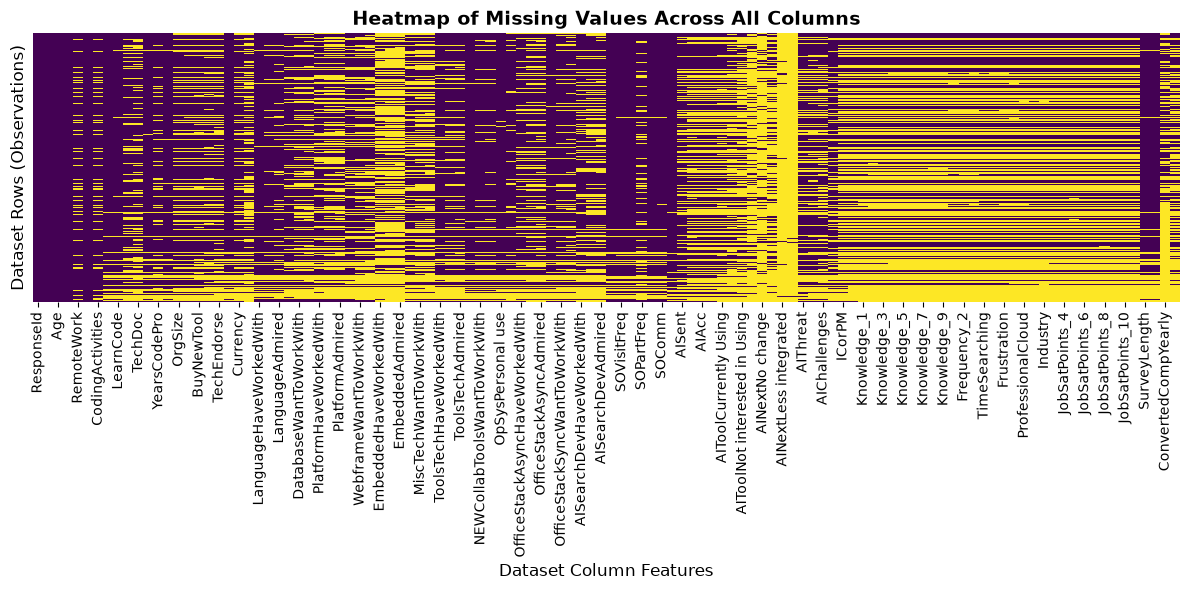

In [7]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot a heatmap visualization of missing data matrices
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# 2. Add structural formatting context anchors 
plt.title('Heatmap of Missing Values Across All Columns', fontsize=14, fontweight='bold')
plt.xlabel('Dataset Column Features', fontsize=12)
plt.ylabel('Dataset Rows (Observations)', fontsize=12)

plt.tight_layout()
plt.show()


##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [8]:
## Write your code here
# Count the number of missing rows in the Employment column
missing_employment = df['Employment'].isnull().sum()

print("Number of missing rows in the 'Employment' column:", missing_employment)


Number of missing rows in the 'Employment' column: 0

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [9]:
## Write your code here
# Identify the most frequent (majority) value in the Employment column
employment_mode = df['Employment'].mode()[0]

print("The most frequent (majority) value in the 'Employment' column is:", employment_mode)


The most frequent (majority) value in the 'Employment' column is: Employed, full-time

##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [10]:
## Write your code here
# Impute missing values in the Employment column with the most frequent value
df['Employment'] = df['Employment'].fillna(employment_mode[0])

# Verify that there are no more missing values left in this column
print("Remaining missing rows in 'Employment' column:", df['Employment'].isnull().sum())


Remaining missing rows in 'Employment' column: 0

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


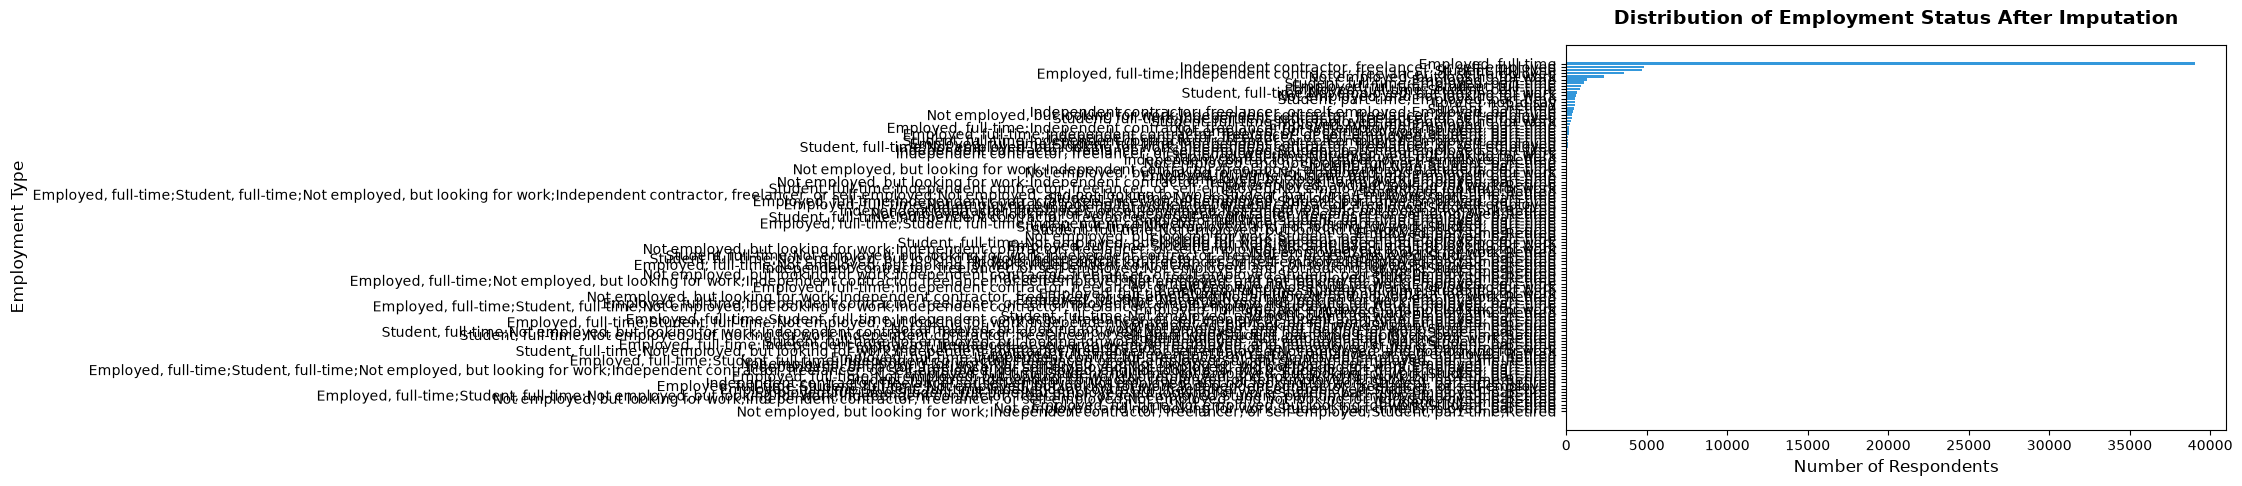

In [12]:
import matplotlib.pyplot as plt

# 1. Calculate the value frequencies of the Employment column after imputation
employment_counts = df['Employment'].value_counts()

# 2. Generate a wider chart window layout
plt.figure(figsize=(12, 5))
plt.barh(employment_counts.index, employment_counts.values, color='#3498db')

# 3. Add titles and axis labels
plt.title('Distribution of Employment Status After Imputation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Employment Type', fontsize=12)
plt.gca().invert_yaxis()  # Keeps the most frequent category at the top

# 4. Manually pad the left margin so long text fits perfectly without warnings
plt.subplots_adjust(left=0.35)

plt.show()


### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
